In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
customer_data = pd.read_csv("customer_data_with_value_segments.csv")
customer_data.head()

,index,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,...,net_revenue,net_to_gross_ratio,churn_class,avg_basket_quantity,avg_unique_items_per_basket,avg_basket_monetary_value,buyer_type,value_segment,segment_name,churn_value_segment
0,0,12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,...,-51.74,-0.138765,churned,6.363636,3.0,33.896364,retail_buyer,2,Low Value Mass Shoppers,churned_Low Value Mass Shoppers
1,1,12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,...,1323.32,1.000000,active,414.000000,35.5,661.660000,retail_buyer,0,Versatile Mid-Tier,active_Versatile Mid-Tier
2,2,12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,...,222.16,1.000000,one_off_buyer,373.000000,20.0,222.160000,retail_buyer,2,Low Value Mass Shoppers,one_off_buyer_Low Value Mass Shoppers
3,3,12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,...,2646.99,0.990959,active,331.000000,34.0,890.380000,retail_buyer,0,Versatile Mid-Tier,active_Versatile Mid-Tier
4,4,12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,...,300.93,1.000000,one_off_buyer,261.000000,21.0,300.930000,retail_buyer,2,Low Value Mass Shoppers,one_off_buyer_Low Value Mass Shoppers


In [3]:
customer_data.shape

(4312, 25)

In [4]:
customer_data = customer_data[customer_data["Customer ID"].notna()]

# Revenue Concentration

## Pareto-style Revenue Concentration

In [5]:
# pareto-style plot of customers with revenue
customer_data_sorted = customer_data.sort_values(by='gross_revenue', ascending=False)
print(customer_data_sorted[['Customer ID', 'gross_revenue']].head(5))
print(customer_data[['Customer ID', 'gross_revenue']].tail(5))

      Customer ID  gross_revenue
4183      18102.0      349164.35
1637      14646.0      248396.50
1269      14156.0      196549.74
1840      14911.0      152121.22
939       13694.0      131443.19
      Customer ID  gross_revenue
4307      18283.0         619.37
4308      18284.0         461.68
4309      18285.0         427.00
4310      18286.0        1296.43
4311      18287.0        2345.71


In [6]:
# calculate total revenue and percentage of revenue for each customer
total_revenue = customer_data_sorted['gross_revenue'].sum()
customer_data_sorted['individual_perc'] = (customer_data_sorted['gross_revenue'] / total_revenue * 100)

# Calculate the cumulative percentage of revenue
customer_data_sorted['cum_perc'] = customer_data_sorted['individual_perc'].cumsum()

# Identify customers contributing to the top 80%
top_80_customers = customer_data_sorted[customer_data_sorted['cum_perc'] <= 80]

# Calculate the metrics
num_customers_80 = len(top_80_customers)
perc_customers_80 = (num_customers_80 / len(customer_data_sorted)) * 100

print(f"Number of customers contributing to 80% revenue: {num_customers_80}")
print(f"Percentage of customer base: {perc_customers_80:.2f}%")

display(customer_data_sorted[['Customer ID', 'gross_revenue', 'cum_perc']].head(5))

Number of customers contributing to 80% revenue: 1171
Percentage of customer base: 27.16%


,Customer ID,gross_revenue,cum_perc
4183,18102.0,349164.35,3.968573
1637,14646.0,248396.50,6.791827
1269,14156.0,196549.74,9.025796
1840,14911.0,152121.22,10.754793
939,13694.0,131443.19,12.248765


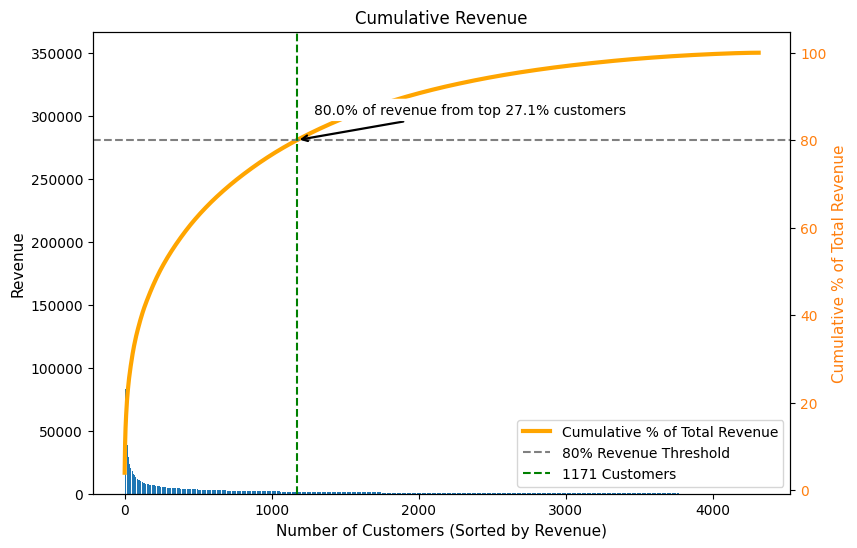

In [7]:
# plot cumulative revenue percentage vs customer count
fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.bar(range(len(customer_data_sorted)), customer_data_sorted['gross_revenue'])
ax1.set_ylabel('Revenue', fontsize=11)
ax1.set_xlabel('Number of Customers (Sorted by Revenue)', fontsize=11)

ax2 = ax1.twinx()
ax2.plot(range(len(customer_data_sorted)), customer_data_sorted['cum_perc'], 
         color='orange', linewidth=3, label='Cumulative % of Total Revenue')
ax2.axhline(y=80, color='gray', linestyle='--', label='80% Revenue Threshold')
ax2.axvline(x=num_customers_80, color='g', linestyle='--', label=f'{num_customers_80} Customers')
ax2.set_ylabel('Cumulative % of Total Revenue', color='C1', fontsize=11)
ax2.tick_params(axis='y', labelcolor='C1')

# annotate 80 percent of revenue captured by top 27.16% customers
idx_27 = int(np.ceil(0.2716 * len(customer_data_sorted))) - 1
rev_at_27 = customer_data_sorted['cum_perc'].iloc[idx_27] 
#ax2.axvline(idx_27, color='gray', linestyle='--', linewidth=1)
#ax2.axhline(rev_at_27, color='gray', linestyle='--', linewidth=1)
ax2.annotate(f'{rev_at_27:.1f}% of revenue from top 27.1% customers',
                 xy=(idx_27, rev_at_27),
                 xytext=(idx_27 + max(5, int(len(customer_data_sorted)*0.0271)), min(98, rev_at_27 + 6)),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.6),
                 fontsize= 10,
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none'))

plt.title('Cumulative Revenue')

plt.legend()
plt.show()

### Add Whale vs Long-Tail Segments

In [8]:
def add_retention_tiers(df, threshold=1171):
    """
    Categorizes customers into 'Whale' and 'Long-tail' based on row position.
    Assumes dataframe is already sorted by revenue descending.
    """
    # Initialize all as Long-tail
    df['is_top27'] = 'Long-tail'
    
    # Assign 'Whale' to the top 1171 rows
    df.iloc[:threshold, df.columns.get_loc('is_top27')] = 'Whale'
    
    return df

# Apply to your data
customer_data = add_retention_tiers(customer_data_sorted)
customer_data[['Customer ID', 'gross_revenue', 'is_top27', 'value_segment', 'segment_name']].head(5)

,Customer ID,gross_revenue,is_top27,value_segment,segment_name
4183,18102.0,349164.35,Whale,3,Frequent Champions
1637,14646.0,248396.50,Whale,3,Frequent Champions
1269,14156.0,196549.74,Whale,3,Frequent Champions
1840,14911.0,152121.22,Whale,3,Frequent Champions
939,13694.0,131443.19,Whale,3,Frequent Champions


### Feature Aggregations Whales vs Long-Tail

e.g.,
- Average order value

In [9]:
# confirm col
customer_data_sorted["is_top27"].value_counts()

is_top27
Long-tail    3141
Whale        1171
Name: count, dtype: int64

In [10]:
customer_data_sorted.columns

Index(['index', 'Customer ID', 'gross_revenue', 'frequency', 'AOV',
       'recency_days', 'tenure_days', 'purchase_rate_monthly',
       'avg_days_between', 'std_days_between', 'return_events',
       'returned_quantity', 'purchased_quantity', 'return_rate',
       'return_value', 'net_revenue', 'net_to_gross_ratio', 'churn_class',
       'avg_basket_quantity', 'avg_unique_items_per_basket',
       'avg_basket_monetary_value', 'buyer_type', 'value_segment',
       'segment_name', 'churn_value_segment', 'individual_perc', 'cum_perc',
       'is_top27'],
      dtype='object')

In [11]:
comparison_data = customer_data_sorted.groupby('is_top27').agg({
    'Customer ID': 'count',
    'gross_revenue': 'sum',
    'returned_quantity': 'sum',
    'purchased_quantity': 'sum',
    'return_value': 'sum',
    'return_events': 'sum',
    'frequency': 'sum'
}).reset_index()

comparison_data['return_rate'] = (comparison_data['returned_quantity'] / comparison_data['purchased_quantity']) * 100
comparison_data['AOV'] = comparison_data['gross_revenue'] / comparison_data['frequency']
comparison_data['units_per_return_event'] = comparison_data['returned_quantity'] / comparison_data['return_events']
comparison_data['gross_intent'] = comparison_data["gross_revenue"] + comparison_data["return_value"]

display(comparison_data)

,is_top27,Customer ID,gross_revenue,returned_quantity,purchased_quantity,return_value,return_events,frequency,return_rate,AOV,units_per_return_event,gross_intent
0,Long-tail,3141,1759972.583,16080.0,1054947,50617.53,1292.0,7011,1.524247,251.030179,12.445820,1810590.113
1,Whale,1171,7038261.161,194849.0,4464631,370149.16,3005.0,12202,4.364280,576.812093,64.841597,7408410.321


In [12]:
cost_per_returned_item = 370149.16 / 194849.0
diff_whale_long_tail = 194849.0 - 16080.0
diff_cost = cost_per_returned_item * diff_whale_long_tail
cost_processing = diff_whale_long_tail * 2
total_cost_saved = diff_cost + cost_processing

print(cost_per_returned_item)
print(diff_whale_long_tail)
print(diff_cost)
print(cost_processing)
print(total_cost_saved)

1.89967184845701
178769.0
339602.43667681125
357538.0
697140.4366768112


### Churn Analysis

In [13]:
df = customer_data_sorted.copy()
churn_breakdown = pd.crosstab(df['is_top27'], df['churn_class'], margins=True)

print(churn_breakdown)

churn_class  active  churned  one_off_buyer   All
is_top27                                         
Long-tail      1237      508           1396  3141
Whale          1022      126             23  1171
All            2259      634           1419  4312


In [14]:
churn_only = df[df['churn_class'] != 'one_off_buyer']

### Kmeans Segment Analysis

In [15]:
cluster_breakdown = pd.crosstab(df['is_top27'], df['segment_name'], margins=True)

display(cluster_breakdown)

segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier,All
is_top27,,,,,
Long-tail,0,0,2715,426,3141
Whale,2,5,847,317,1171
All,2,5,3562,743,4312


<Axes: xlabel='is_top27'>

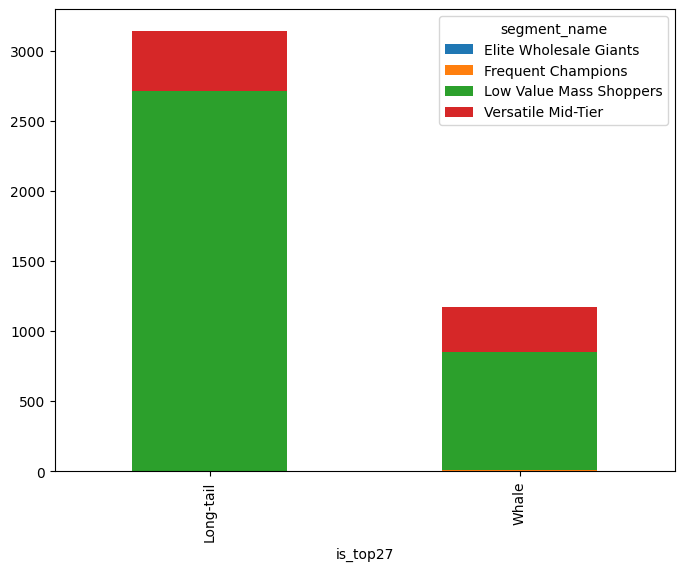

In [16]:
# Create the composition plot
# Create the composition plot
composition = pd.crosstab(df['is_top27'], df['segment_name'])
composition.plot(kind='bar', stacked=True, figsize=(8,6))

In [17]:
#repeat_customers_only = df[df['churn_class'] != 'one_off_buyer']
grp = df.groupby(['is_top27', 'churn_class'])['value_segment'].value_counts()

display(grp)

is_top27   churn_class    value_segment
Long-tail  active         2                1087
                          0                 150
           churned        2                 470
                          0                  38
           one_off_buyer  2                1158
                          0                 238
Whale      active         2                 761
                          0                 256
                          3                   5
           churned        2                  86
                          0                  39
                          1                   1
           one_off_buyer  0                  22
                          1                   1
Name: count, dtype: int64

gment_map = {0: 'Versatile Mid-Tier', 1: 'Elite Wholesale Giants', 2: 'Low Value Mass Shoppers', 3: 'Frequent Champions'}

In [18]:
#Pivot the clusters to columns
nice_table = grp.unstack(level='value_segment').fillna(0).astype(int)

# 2. Add a 'Total' column for context
nice_table['Total'] = nice_table.sum(axis=1)

print(nice_table)

value_segment              0  1     2  3  Total
is_top27  churn_class                          
Long-tail active         150  0  1087  0   1237
          churned         38  0   470  0    508
          one_off_buyer  238  0  1158  0   1396
Whale     active         256  0   761  5   1022
          churned         39  1    86  0    126
          one_off_buyer   22  1     0  0     23


In [19]:
pip install jinja2

Note: you may need to restart the kernel to use updated packages.


In [20]:
# Normalize by row to see the percentage composition
composition_pct = nice_table.div(nice_table['Total'], axis=0) * 100

# Format for the report
styled_table = composition_pct.drop(columns='Total').style.format("{:.1f}%").background_gradient(cmap='Blues').set_properties(**{'font_size': '14pt','width': '80px', 'height': '40px', 'text_align': 'center'})
styled_table

File saved: segment_lifecycle_heatmap.png


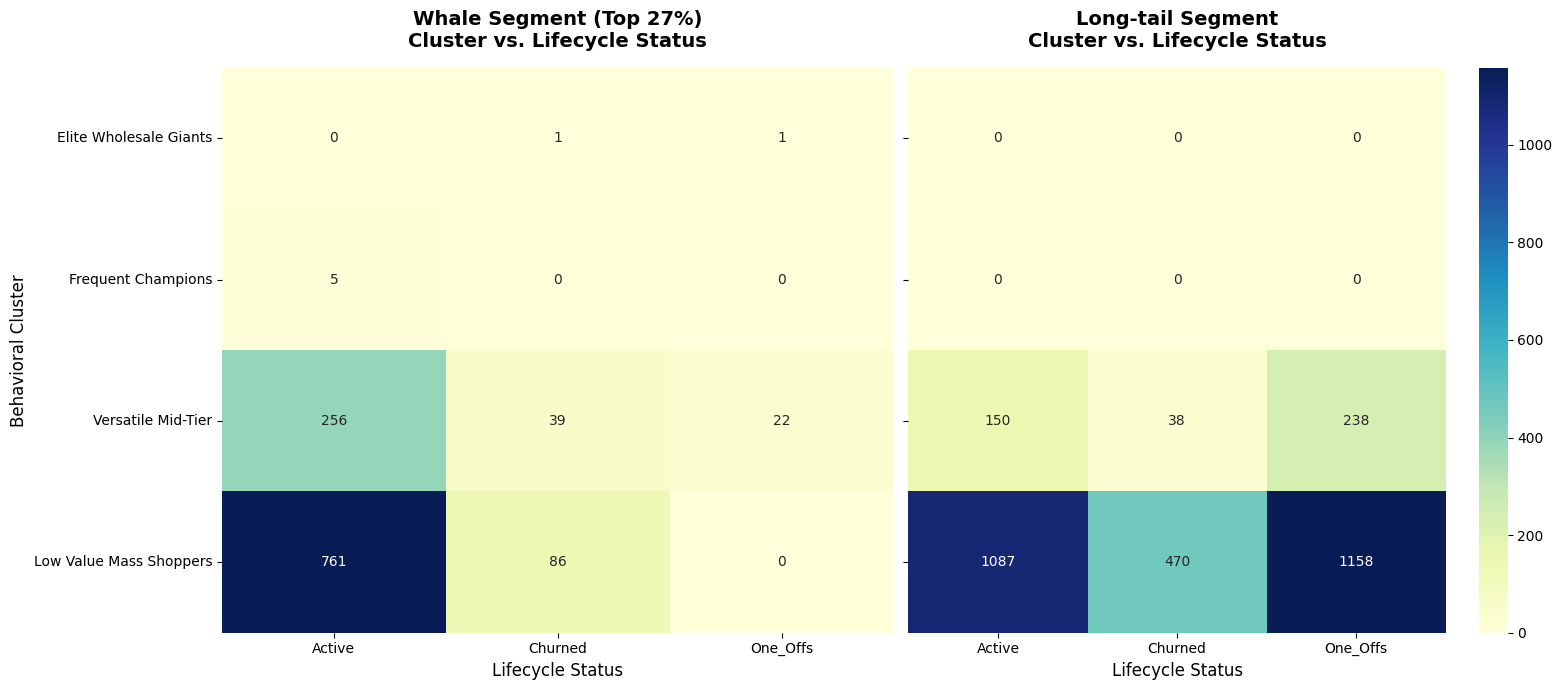

In [21]:
# heatmap
# Data for Whale segment
whale_data = {
    'Active': [0, 5, 256, 761],
    'Churned': [1, 0, 39, 86],
    'One_Offs': [1, 0, 22, 0]
}
whale_index = ['Elite Wholesale Giants', 'Frequent Champions', 'Versatile Mid-Tier', 'Low Value Mass Shoppers']
df_whale = pd.DataFrame(whale_data, index=whale_index)

# Data for Long-tail segment
lt_data = {
    'Active': [0, 0, 150, 1087],
    'Churned': [0, 0, 38, 470],
    'One_Offs': [0, 0, 238, 1158]
}
lt_index = ['Elite Wholesale Giants', 'Frequent Champions', 'Versatile Mid-Tier', 'Low Value Mass Shoppers']
df_lt = pd.DataFrame(lt_data, index=lt_index)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Whale Heatmap
sns.heatmap(df_whale, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0], cbar=False)
axes[0].set_title('Whale Segment (Top 27%)\nCluster vs. Lifecycle Status', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Lifecycle Status', fontsize=12)
axes[0].set_ylabel('Behavioral Cluster', fontsize=12)

# Long-tail Heatmap
sns.heatmap(df_lt, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1], cbar=True)
axes[1].set_title('Long-tail Segment\nCluster vs. Lifecycle Status', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Lifecycle Status', fontsize=12)
axes[1].set_ylabel('') # Hidden for sharey

plt.tight_layout()
plt.savefig("segment_lifecycle_heatmap.png")
print("File saved: segment_lifecycle_heatmap.png")

### Revenue vs. Friction" Matrix (The Money View)

In [22]:
# Aggregate total revenue by segment and cluster
revenue_map = df.groupby(['is_top27', 'segment_name'])['gross_revenue'].sum().unstack().fillna(0)

# Calculate the % of total company revenue
revenue_share = (revenue_map / df['gross_revenue'].sum()) * 100

print("Revenue contribution")
display(revenue_map)
print('\n')
print('Revenue share:')
display(revenue_share)

Revenue contribution


segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,0.0,0.0,1446074.192,313898.391
Whale,45976.1,1077675.0,3976955.818,1937654.243




Revenue share:


segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,0.000000,0.000000,16.435960,3.567743
Whale,0.522561,12.248765,45.201752,22.023219


In [23]:
# transactions
display(df.groupby(['is_top27', 'segment_name'])['frequency'].sum().unstack().fillna(0))

segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,0.0,0.0,6236.0,775.0
Whale,6.0,568.0,9371.0,2257.0


In [24]:
# return quantity
qrt_r = df.groupby(['is_top27', 'segment_name'])['returned_quantity'].sum().unstack().fillna(0)

# purchased quantity
qrty_p = df.groupby(['is_top27', 'segment_name'])['purchased_quantity'].sum().unstack().fillna(0)

# return rate
rates = (qrt_r / qrty_p) * 100
print("Returned quantity:")
display(qrt_r)
print("\n")
print("Purchased Quantity:")
display(qrty_p)
print("\n")
print("Return rate:")
display(rates)

Returned quantity:


segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,0.0,0.0,14685.0,1395.0
Whale,2510.0,9682.0,55284.0,127373.0




Purchased Quantity:


segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,0.0,0.0,860942.0,194005.0
Whale,307767.0,598201.0,2238146.0,1320517.0




Return rate:


segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,NaN,NaN,1.70569,0.719054
Whale,0.815552,1.61852,2.47008,9.645692


In [25]:
# return events
events = df.groupby(['is_top27', 'segment_name'])['return_events'].sum().unstack().fillna(0)
items_event = qrt_r / events

print("No. of return events:")
display(events)
print("\n")
print("Average No. of items per return event:")
display(items_event)

No. of return events:


segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,0.0,0.0,1168.0,124.0
Whale,3.0,127.0,2224.0,651.0




Average No. of items per return event:


segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,NaN,NaN,12.572774,11.25000
Whale,836.666667,76.23622,24.857914,195.65745


In [26]:
# return vale
r_value = df.groupby(['is_top27', 'segment_name'])['return_value'].sum().unstack().fillna(0)
per_item = r_value / qrt_r 

print("Return value:")
display(r_value)
print("\n")
print("Average price per returned item:")
display(per_item)

Return value:


segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,0.0,0.00,46923.99,3693.54
Whale,3684.0,42998.49,169078.93,154387.74




Average price per returned item:


segment_name,Elite Wholesale Giants,Frequent Champions,Low Value Mass Shoppers,Versatile Mid-Tier
is_top27,,,,
Long-tail,NaN,NaN,3.195369,2.647699
Whale,1.467729,4.441075,3.058370,1.212092


### Financial weight for behavioral clusters

In [27]:
# Aggregate total revenue by cluster
revenue_map = df.groupby('segment_name')['gross_revenue'].sum()

# Calculate the % of total company revenue
revenue_share = (revenue_map / df['gross_revenue'].sum()) * 100

print("Revenue contribution")
display(revenue_map)
print('\n')
print('Revenue share:')
display(revenue_share)

Revenue contribution


segment_name
Elite Wholesale Giants       45976.100
Frequent Champions         1077675.000
Low Value Mass Shoppers    5423030.010
Versatile Mid-Tier         2251552.634
Name: gross_revenue, dtype: float64



Revenue share:


segment_name
Elite Wholesale Giants      0.522561
Frequent Champions         12.248765
Low Value Mass Shoppers    61.637712
Versatile Mid-Tier         25.590962
Name: gross_revenue, dtype: float64

In [28]:
# plot segment revenue vs customer share
segment_revenue = customer_data.groupby(['segment_name']).agg({
    'gross_revenue': 'sum',
    'Customer ID': 'count',
    'returned_quantity': 'sum',
    'purchased_quantity': 'sum'
}).rename(columns={'gross_revenue': 'Total Revenue', 'Customer ID': 'Customer No.'})

print(segment_revenue)

# calculate the percentage of customers for each segment
segment_revenue['Customer Share'] = (segment_revenue['Customer No.'] / segment_revenue['Customer No.'].sum() * 100).round(2).apply(lambda x: f"{x:.2f}%")

# calculate the percentage of total revenue for each segment
total_revenue = segment_revenue['Total Revenue'].sum()
segment_revenue['Revenue Share'] = (segment_revenue['Total Revenue'] / total_revenue * 100).round(2).apply(lambda x: f"{x:.2f}%")

# return rate
segment_revenue['return_rate'] = (segment_revenue['returned_quantity'] / segment_revenue['purchased_quantity'])* 100

display(segment_revenue.sort_values(by='Revenue Share', ascending=False))

                         Total Revenue  Customer No.  returned_quantity  \
segment_name                                                              
Elite Wholesale Giants       45976.100             2             2510.0   
Frequent Champions         1077675.000             5             9682.0   
Low Value Mass Shoppers    5423030.010          3562            69969.0   
Versatile Mid-Tier         2251552.634           743           128768.0   

                         purchased_quantity  
segment_name                                 
Elite Wholesale Giants               307767  
Frequent Champions                   598201  
Low Value Mass Shoppers             3099088  
Versatile Mid-Tier                  1514522  


,Total Revenue,Customer No.,returned_quantity,purchased_quantity,Customer Share,Revenue Share,return_rate
segment_name,,,,,,,
Low Value Mass Shoppers,5423030.010,3562,69969.0,3099088,82.61%,61.64%,2.257729
Versatile Mid-Tier,2251552.634,743,128768.0,1514522,17.23%,25.59%,8.502221
Frequent Champions,1077675.000,5,9682.0,598201,0.12%,12.25%,1.618520
Elite Wholesale Giants,45976.100,2,2510.0,307767,0.05%,0.52%,0.815552


In [29]:
# select top segments for plotting
top3_segments = segment_revenue.sort_values(by='Revenue Share', ascending=False).head(3)

# convert to dataframe for better display
top3_segments_df = top3_segments.reset_index()

display(top3_segments_df[['segment_name', 'Customer Share', 'Revenue Share']])

,segment_name,Customer Share,Revenue Share
0,Low Value Mass Shoppers,82.61%,61.64%
1,Versatile Mid-Tier,17.23%,25.59%
2,Frequent Champions,0.12%,12.25%


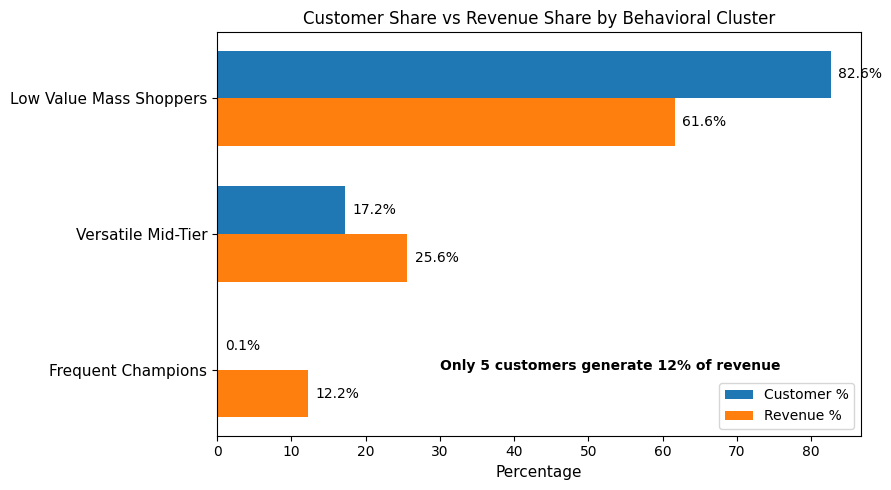

In [30]:
# plot customer share vs revenue share by segment using a scatter plot

fig, ax = plt.subplots(figsize=(9, 5))

# sort by revenue share descending
sorted_df = top3_segments_df.sort_values(by='Revenue Share', ascending=False)

y = np.arange(len(sorted_df))
height = 0.35

bars1 = ax.barh(
    y - height/2,
    sorted_df['Customer Share'].str.rstrip('%').astype(float),
    height,
    label='Customer %'
)

bars2 = ax.barh(
    y + height/2,
    sorted_df['Revenue Share'].str.rstrip('%').astype(float),
    height,
    label='Revenue %'
)

# annotate
for bar in list(bars1) + list(bars2):
    width = bar.get_width()
    ax.text(width + 1,
            bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            va='center',
            fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(sorted_df['segment_name'], fontsize=11)

ax.set_xlabel('Percentage', fontsize=11)
ax.set_title('Customer Share vs Revenue Share by Behavioral Cluster')

ax.text(
    30,
    2,
    "Only 5 customers generate 12% of revenue",
    fontsize=10,
    weight='bold'
)

ax.legend()

ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Lifecycle Funnel

In [31]:
# classify customers into lifecycle stages
def classify_customer(x):
    if x == 1:
        return "First Purchase"
    elif x <= 4:
        return "Repeat Customer"
    else:
        return "Long-Term Customer"

customer_data["lifecycle_stage"] = customer_data["frequency"].apply(classify_customer)

# count customers per stage
funnel = customer_data["lifecycle_stage"].value_counts().reset_index()
funnel.columns = ["Stage", "Customers"]

print(funnel)

                Stage  Customers
0     Repeat Customer       1713
1      First Purchase       1419
2  Long-Term Customer       1180


In [32]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [33]:
#%pip install --upgrade nbformat

# visualize funnel
import plotly.express as px

fig = px.funnel(
    funnel,
    x="Customers",
    y="Stage",
    color_discrete_sequence=["#298fb0"],
    width = 800,
    height = 350,
    title = "Customer Lifecycle" 
)
fig.update_layout(font=dict(size=15))
# Remove background colors
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')

# Adjust margins to make the funnel fill more/less horizontal space
fig.update_layout(margin=dict(l=50, r=50, t=50, b=50))
fig.show()

## Operational Efficiency Insight

### Net Revenue Efficiency

**Which segments produce clean revenue?**

In [34]:
comparison_data = customer_data_sorted.groupby(['is_top27', 'segment_name']).agg({
    'Customer ID': 'count',
    'gross_revenue': 'sum',
    'returned_quantity': 'sum',
    'purchased_quantity': 'sum',
    'return_value': 'sum',
    'return_events': 'sum',
    'frequency': 'sum',
    "frequency": "mean",
    'purchase_rate_monthly': 'mean',
    #'tenure_days': "min",
    #"tenure_days": "max"
    "tenure_days": "mean"
}).reset_index()

comparison_data['return_rate'] = (comparison_data['returned_quantity'] / comparison_data['purchased_quantity']) * 100
comparison_data['units_per_return_event'] = comparison_data['returned_quantity'] / comparison_data['return_events']
comparison_data['gross_intent'] = comparison_data["gross_revenue"] + comparison_data["return_value"]
comparison_data['net_revenue'] = comparison_data['gross_revenue'] - comparison_data['return_value']
comparison_data['net_gross_ratio'] = comparison_data['net_revenue'] / comparison_data['gross_revenue']
comparison_data['revenue_share'] = comparison_data['gross_revenue'] / customer_data_sorted['gross_revenue'].sum()

display(comparison_data)

,is_top27,segment_name,Customer ID,gross_revenue,returned_quantity,purchased_quantity,return_value,return_events,frequency,purchase_rate_monthly,tenure_days,return_rate,units_per_return_event,gross_intent,net_revenue,net_gross_ratio,revenue_share
0,Long-tail,Low Value Mass Shoppers,2715,1446074.192,14685.0,860942,46923.99,1168.0,2.296869,14.910778,91.649355,1.705690,12.572774,1492998.182,1399150.202,0.967551,0.164360
1,Long-tail,Versatile Mid-Tier,426,313898.391,1395.0,194005,3693.54,124.0,1.819249,18.070740,68.680751,0.719054,11.250000,317591.931,310204.851,0.988233,0.035677
2,Whale,Elite Wholesale Giants,2,45976.100,2510.0,307767,3684.00,3.0,3.000000,15.806452,47.000000,0.815552,836.666667,49660.100,42292.100,0.919871,0.005226
3,Whale,Frequent Champions,5,1077675.000,9682.0,598201,42998.49,127.0,113.600000,9.231420,368.000000,1.618520,76.236220,1120673.490,1034676.510,0.960101,0.122488
4,Whale,Low Value Mass Shoppers,847,3976955.818,55284.0,2238146,169078.93,2224.0,11.063754,2.134412,275.260921,2.470080,24.857914,4146034.748,3807876.888,0.957485,0.452018
5,Whale,Versatile Mid-Tier,317,1937654.243,127373.0,1320517,154387.74,651.0,7.119874,4.578867,217.501577,9.645692,195.657450,2092041.983,1783266.503,0.920322,0.220232


In [35]:
comparison_data['segments'] = comparison_data["is_top27"] + comparison_data['segment_name']
comparison_data['segments']

0    Long-tailLow Value Mass Shoppers
1         Long-tailVersatile Mid-Tier
2         WhaleElite Wholesale Giants
3             WhaleFrequent Champions
4        WhaleLow Value Mass Shoppers
5             WhaleVersatile Mid-Tier
Name: segments, dtype: object

In [36]:
# scatterplot of net_gross_ratio
#comparison_data['segments'] = comparison_data["is_top27"] + comparison_data['segment_name']
fig = px.scatter(comparison_data, x = 'revenue_share', y = 'net_gross_ratio', color = 'segment_name',
                 size = 'Customer ID', hover_name = 'is_top27', size_max= 100,
                 title = "Revenue Quality by Customer Segment",
                 width = 1300,
                 height = 550)
fig.update_layout(font=dict(size=15))
fig.update_layout(
    yaxis_title="Net to Gross Revenue Ratio",
    xaxis_title="Revenue Share %",
)
#fig.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')

# Adjust margins to make the funnel fill more/less horizontal space
fig.update_layout(margin=dict(l=50, r=50, t=50, b=50))
#fig.update_traces(marker_size=20)
fig.show()

Interpretation:

0.95 → clean revenue

0.80 → heavy return leakage

**Are we building long-term customers or short-term transactions?**

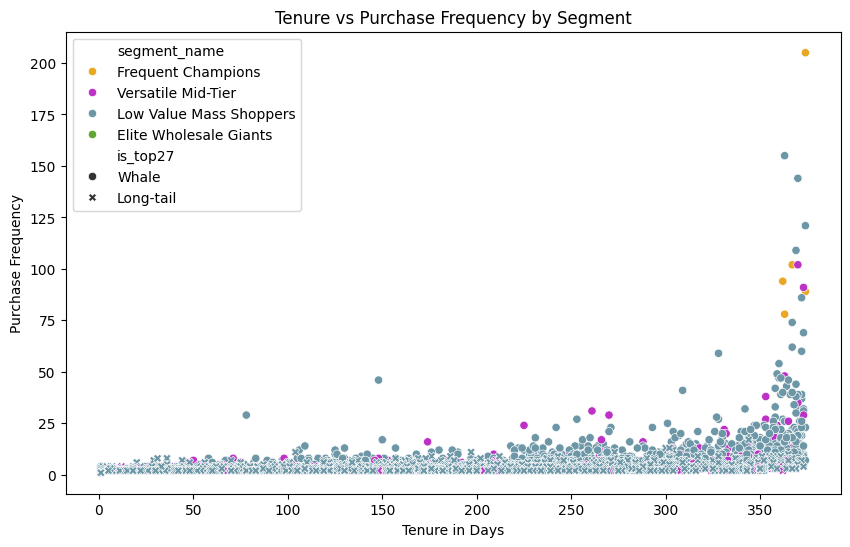

In [37]:
# tenure vs frequency
palette = ["#e9a723", "#bb32c5", "#6d97a6", "#5fa835"]
plt.figure(figsize = [10,6])
sns.scatterplot(customer_data_sorted, x = 'tenure_days', y = 'frequency', hue = 'segment_name', 
                style = 'is_top27', palette= palette)
plt.title('Tenure vs Purchase Frequency by Segment')
plt.ylabel("Purchase Frequency")
plt.xlabel('Tenure in Days')
plt.show()

In [38]:
customer_data_sorted['tenure_months'] = customer_data_sorted['tenure_days'] / 30
customer_data_sorted['engagement_ratio'] = customer_data_sorted['frequency'] / customer_data_sorted['tenure_months']
display(customer_data_sorted.head(10))

,index,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,...,buyer_type,value_segment,segment_name,churn_value_segment,individual_perc,cum_perc,is_top27,lifecycle_stage,tenure_months,engagement_ratio
4183,4183,18102.0,349164.35,89,3923.194944,0,374,7.139037,0.555911,3.029071,...,wholesale_buyer,3,Frequent Champions,active_Frequent Champions,3.968573,3.968573,Whale,Long-Term Customer,12.466667,7.139037
1637,1637,14646.0,248396.50,78,3184.570513,9,363,6.446281,0.191309,1.650445,...,wholesale_buyer,3,Frequent Champions,active_Frequent Champions,2.823254,6.791827,Whale,Long-Term Customer,12.100000,6.446281
1269,1269,14156.0,196549.74,102,1926.958235,6,367,8.337875,0.122117,0.972301,...,wholesale_buyer,3,Frequent Champions,active_Frequent Champions,2.233968,9.025796,Whale,Long-Term Customer,12.233333,8.337875
1840,1840,14911.0,152121.22,205,742.054732,0,374,16.443850,0.052991,0.586310,...,retail_buyer,3,Frequent Champions,active_Frequent Champions,1.728997,10.754793,Whale,Long-Term Customer,12.466667,16.443850
939,939,13694.0,131443.19,94,1398.331809,8,362,7.790055,0.352510,2.163525,...,wholesale_buyer,3,Frequent Champions,active_Frequent Champions,1.493972,12.248765,Whale,Long-Term Customer,12.066667,7.790055
3744,3744,17511.0,84541.17,31,2727.134516,2,370,2.513514,0.372756,2.705686,...,wholesale_buyer,0,Versatile Mid-Tier,active_Versatile Mid-Tier,0.960888,13.209653,Whale,Long-Term Customer,12.333333,2.513514
1951,1951,15061.0,83284.38,86,968.423023,2,372,6.935484,0.596913,3.071953,...,wholesale_buyer,2,Low Value Mass Shoppers,active_Low Value Mass Shoppers,0.946603,14.156257,Whale,Long-Term Customer,12.400000,6.935484
3128,3128,16684.0,80489.21,27,2981.081852,14,353,2.294618,0.786364,5.068532,...,wholesale_buyer,0,Versatile Mid-Tier,active_Versatile Mid-Tier,0.914834,15.071090,Whale,Long-Term Customer,11.766667,2.294618
3177,3177,16754.0,65500.07,29,2258.623103,7,270,3.222222,1.870504,6.352946,...,wholesale_buyer,0,Versatile Mid-Tier,active_Versatile Mid-Tier,0.744468,15.815559,Whale,Long-Term Customer,9.000000,3.222222
4065,4065,17949.0,60117.60,74,812.400000,6,367,6.049046,4.023256,6.684445,...,retail_buyer,2,Low Value Mass Shoppers,active_Low Value Mass Shoppers,0.683292,16.498850,Whale,Long-Term Customer,12.233333,6.049046


In [39]:
customer_data_sorted['segment'] = customer_data_sorted['is_top27'] + (' ') + customer_data_sorted['segment_name']

In [40]:
# Customer Purchase Intensity by Segment
segment_engagement = (
    customer_data_sorted.groupby(['segment'])['frequency'].sum()
    /
    customer_data_sorted.groupby(['segment'])['tenure_months'].sum()
)
display(segment_engagement)

segment
Long-tail Low Value Mass Shoppers    0.751845
Long-tail Versatile Mid-Tier         0.794654
Whale Elite Wholesale Giants         1.914894
Whale Frequent Champions             9.260870
Whale Low Value Mass Shoppers        1.205811
Whale Versatile Mid-Tier             0.982044
dtype: float64

### AOV

In [41]:
# segment AOV
segment_aov = (
    customer_data_sorted.groupby(['segment'])['gross_revenue'].sum()
    /
    customer_data_sorted.groupby(['segment'])['frequency'].sum()
)
display(segment_aov)

segment
Long-tail Low Value Mass Shoppers     231.891307
Long-tail Versatile Mid-Tier          405.030182
Whale Elite Wholesale Giants         7662.683333
Whale Frequent Champions             1897.315141
Whale Low Value Mass Shoppers         424.389694
Whale Versatile Mid-Tier              858.508747
dtype: float64

In [42]:
# Monthly Revenue per Customer=Purchase Rate×AOV

monthly_revenue = segment_engagement * segment_aov
display(monthly_revenue)

segment
Long-tail Low Value Mass Shoppers      174.346238
Long-tail Versatile Mid-Tier           321.859038
Whale Elite Wholesale Giants         14673.223404
Whale Frequent Champions             17570.788043
Whale Low Value Mass Shoppers          511.733740
Whale Versatile Mid-Tier               843.093742
dtype: float64

In [43]:
plotting = customer_data_sorted.groupby(['segment']).agg({
    'Customer ID': 'count',
    'frequency': 'mean',
    'gross_revenue': 'sum'

})
plotting['AOV'] = segment_aov
plotting

,Customer ID,frequency,gross_revenue,AOV
segment,,,,
Long-tail Low Value Mass Shoppers,2715,2.296869,1446074.192,231.891307
Long-tail Versatile Mid-Tier,426,1.819249,313898.391,405.030182
Whale Elite Wholesale Giants,2,3.000000,45976.100,7662.683333
Whale Frequent Champions,5,113.600000,1077675.000,1897.315141
Whale Low Value Mass Shoppers,847,11.063754,3976955.818,424.389694
Whale Versatile Mid-Tier,317,7.119874,1937654.243,858.508747


In [44]:
# plot
plotting = plotting.reset_index()

fig = px.scatter(plotting, x = 'frequency', y = 'AOV', color = 'segment',
                 title = "AOV vs Purchase Frequency",
                 width = 900,
                 height = 400)
fig.update_layout(font=dict(size=15))
fig.update_layout(
    xaxis_title="Purchase Frequency",
    yaxis_title="Average Order Value")
#fig.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')

# Adjust margins to make the funnel fill more/less horizontal space
fig.update_layout(margin=dict(l=50, r=50, t=50, b=50))
fig.update_traces(marker_size=20)
fig.show()

In [45]:
one_time_whales = customer_data_sorted[customer_data_sorted['is_top27'] == 'Whale']
one_time_whales2 = one_time_whales[one_time_whales['churn_class'] == 'one_off_buyer']
one_time_whales2

,index,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,...,value_segment,segment_name,churn_value_segment,individual_perc,cum_perc,is_top27,lifecycle_stage,tenure_months,engagement_ratio,segment
933,933,13687.0,11880.840,1,11880.840,73,1,30.0,0.0,0.0,...,1,Elite Wholesale Giants,one_off_buyer_Elite Wholesale Giants,0.135037,36.040147,Whale,First Purchase,0.033333,30.0,Whale Elite Wholesale Giants
374,374,12918.0,10953.500,1,10953.500,261,1,30.0,0.0,0.0,...,0,Versatile Mid-Tier,one_off_buyer_Versatile Mid-Tier,0.124497,37.959867,Whale,First Purchase,0.033333,30.0,Whale Versatile Mid-Tier
4144,4144,18052.0,10877.180,1,10877.180,199,1,30.0,0.0,0.0,...,0,Versatile Mid-Tier,one_off_buyer_Versatile Mid-Tier,0.123629,38.083496,Whale,First Purchase,0.033333,30.0,Whale Versatile Mid-Tier
2712,2712,16118.0,4376.250,1,4376.250,287,1,30.0,0.0,0.0,...,0,Versatile Mid-Tier,one_off_buyer_Versatile Mid-Tier,0.049740,55.694977,Whale,First Purchase,0.033333,30.0,Whale Versatile Mid-Tier
1491,1491,14459.0,3537.821,1,3537.821,286,1,30.0,0.0,0.0,...,0,Versatile Mid-Tier,one_off_buyer_Versatile Mid-Tier,0.040211,61.167430,Whale,First Purchase,0.033333,30.0,Whale Versatile Mid-Tier
545,545,13139.0,3138.040,1,3138.040,72,1,30.0,0.0,0.0,...,0,Versatile Mid-Tier,one_off_buyer_Versatile Mid-Tier,0.035667,64.051257,Whale,First Purchase,0.033333,30.0,Whale Versatile Mid-Tier
114,114,12511.0,3084.020,1,3084.020,63,1,30.0,0.0,0.0,...,0,Versatile Mid-Tier,one_off_buyer_Versatile Mid-Tier,0.035053,64.581482,Whale,First Purchase,0.033333,30.0,Whale Versatile Mid-Tier
2576,2576,15939.0,2945.380,1,2945.380,9,1,30.0,0.0,0.0,...,0,Versatile Mid-Tier,one_off_buyer_Versatile Mid-Tier,0.033477,65.709749,Whale,First Purchase,0.033333,30.0,Whale Versatile Mid-Tier
593,593,13205.0,2803.200,1,2803.200,78,1,30.0,0.0,0.0,...,0,Versatile Mid-Tier,one_off_buyer_Versatile Mid-Tier,0.031861,66.654843,Whale,First Purchase,0.033333,30.0,Whale Versatile Mid-Tier
202,202,12671.0,2622.481,1,2622.481,241,1,30.0,0.0,0.0,...,0,Versatile Mid-Tier,one_off_buyer_Versatile Mid-Tier,0.029807,68.201048,Whale,First Purchase,0.033333,30.0,Whale Versatile Mid-Tier


In [46]:
# segment revenue net/gross
net_gross = (
    customer_data_sorted.groupby(['segment'])['net_revenue'].sum()
    /
    customer_data_sorted.groupby(['segment'])['gross_revenue'].sum()
)
display(net_gross)

segment
Long-tail Low Value Mass Shoppers    0.967551
Long-tail Versatile Mid-Tier         0.988233
Whale Elite Wholesale Giants         0.919871
Whale Frequent Champions             0.960101
Whale Low Value Mass Shoppers        0.957485
Whale Versatile Mid-Tier             0.920322
dtype: float64

**Revenue Leakage**

Revenue Leakage = return_value / gross_revenue
	​


In [47]:
# revenue leakage
leakage = (
    customer_data_sorted.groupby(['segment'])['return_value'].sum()
    /
    customer_data_sorted.groupby(['segment'])['gross_revenue'].sum()
) * 100
display(leakage)

segment
Long-tail Low Value Mass Shoppers    3.244923
Long-tail Versatile Mid-Tier         1.176667
Whale Elite Wholesale Giants         8.012859
Whale Frequent Champions             3.989931
Whale Low Value Mass Shoppers        4.251466
Whale Versatile Mid-Tier             7.967765
dtype: float64